<a href="https://colab.research.google.com/github/jaybehare3102/Ai-Python-/blob/main/AlaxNet_on_CIFRA_10(GPU).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Activation,Dropout,BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [8]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
# Normalise Pixel Values
X_train=X_train.astype('float32')/255
X_test=X_test.astype('float32')/255

# One-Hot encoding the Labels
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)


In [9]:
model=Sequential()
# Layer1
model.add(Conv2D(96,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(BatchNormalization())


# Layer2
model.add(Conv2D(256,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(BatchNormalization())

# Layer3
model.add(Conv2D(384,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))


# Layer4
model.add(Conv2D(384,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))


# Layer5
model.add(Conv2D(256,kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(BatchNormalization())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Flattening
model.add(Flatten())

# Fully Connected Layer1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

In [13]:
# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

history=model.fit(X_train,y_train,batch_size=128,epochs=15,validation_split=0.2,verbose=1)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.3975 - loss: 1.7002 - val_accuracy: 0.1446 - val_loss: 8.0147
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.5770 - loss: 1.2003 - val_accuracy: 0.3447 - val_loss: 2.2083
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.6668 - loss: 0.9534 - val_accuracy: 0.5941 - val_loss: 1.2094
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7183 - loss: 0.8192 - val_accuracy: 0.6899 - val_loss: 0.8779
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7607 - loss: 0.6997 - val_accuracy: 0.7318 - val_loss: 0.8088
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7931 - loss: 0.6090 - val_accuracy: 0.7411 - val_loss: 0.7551
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8239 - loss: 0.5210 - val_accuracy: 0.7406 - val_loss: 0.7934
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8507 - loss: 0.4484 - 

In [15]:
test_loss,test_acc = model.evaluate(X_test,y_test)
print('Test Accuracy:',test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7842 - loss: 0.7806
Test Accuracy: 0.7842000126838684


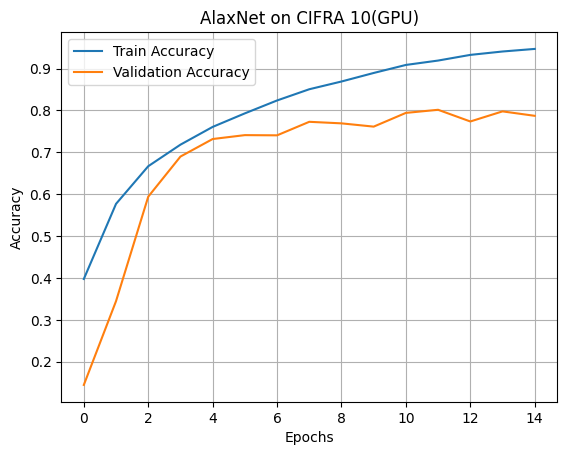

In [18]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('AlaxNet on CIFRA 10(GPU)')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)
plt.show()